# 02 — Experimental figures

Builds the dissertation figures from saved run outputs. Nothing here trains a model, runs inference, or recomputes a metric under a different convention: every figure is a view of one run directory's saved predictions and training history, so each can be traced back to `outputs/<run_id>/`.

Run the setup cell first. It prints which run each section below will read, and flags any synthetic smoke run so it is never mistaken for a result.

In [1]:
# Setup. This notebook is a PRESENTATION LAYER: it reads saved run outputs and calls the
# plotting functions in src.evaluation.plots. Run discovery, smoke-run exclusion, and
# provenance live in src.evaluation.aggregation, so nothing analytical is defined here
# that a script could not reuse. No model is loaded and no metric is recomputed under a
# different convention, so every figure traces back to a specific run directory.
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.aggregation import (
    EXPERIMENT_METRIC_FILES,
    discover_runs,
    load_metrics,
    reportable_runs,
)
from src.evaluation.metrics import (
    compute_binary_metrics,
    confusion_matrix,
    precision_recall_curve_data,
    roc_curve_data,
    threshold_scores,
)
from src.evaluation.plots import (
    plot_confusion_matrix,
    plot_fine_tuning_recovery,
    plot_generalisation_degradation,
    plot_generator_performance,
    plot_parameter_efficiency,
    plot_precision_recall_curves,
    plot_roc_curves,
    plot_training_curves,
)

OUTPUT_ROOT = REPO_ROOT / "outputs"

# Every run under the output root, of every status. reportable_runs() keeps the ones that
# completed AND carry a metrics file AND are not synthetic SMOKE_ fixtures.
RECORDS = discover_runs(OUTPUT_ROOT)
REPORTABLE = reportable_runs(RECORDS)


def newest(experiment_type):
    """Newest reportable run of one protocol, or None. Records are ordered oldest first."""
    matches = [record for record in REPORTABLE if record.experiment_type == experiment_type]
    return matches[-1] if matches else None


RUN_RECORDS = {name: newest(name) for name in EXPERIMENT_METRIC_FILES}
# Downstream cells read prediction/history CSVs straight from the directory.
RUNS = {name: (record.run_dir if record else None) for name, record in RUN_RECORDS.items()}


def metrics_for(experiment_type):
    """The saved metrics dict for one protocol's newest reportable run, or None."""
    record = RUN_RECORDS[experiment_type]
    return load_metrics(record) if record else None


display(
    pd.DataFrame(
        [
            {
                "experiment": name,
                "run": record.run_id if record else "NO REPORTABLE RUN",
                "held_out": record.held_out_generator if record else None,
                "seed": record.seed if record else None,
            }
            for name, record in RUN_RECORDS.items()
        ]
    )
)
skipped = [r for r in RECORDS if r not in REPORTABLE]
if skipped:
    print("Excluded from this notebook:")
    for record in skipped:
        reason = "SYNTHETIC SMOKE" if record.is_synthetic_smoke else record.status
        print(f"  {record.run_id}  [{reason}]")


,experiment,run,held_out,seed
0,baseline,baseline-20260809T150824861195Z-4c050175ac-2692,NaN,42.0
1,unseen_generator,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,42.0
2,fine_tuning,fine_tuning-20260808T171227711418Z-314210675e-...,biggan,42.0
3,ablation,NO REPORTABLE RUN,NaN,NaN


Excluded from this notebook:
  unseen_generator-20260808T144550443491Z-b386ea5c10-bb06  [SYNTHETIC SMOKE]
  fine_tuning-20260808T144640138049Z-6ec6cf50a2-f38d  [SYNTHETIC SMOKE]
  unseen_generator-20260808T150151025524Z-c74c3e0db3-21d6  [failed]
  ablation-20260809T194436211721Z-fc1a22d8e3-5389  [incomplete]


## 1. Confusion matrices — where the errors fall

Counts of the four possible outcomes on the held-out generator's test set: real images correctly passed, fakes correctly caught, real images wrongly flagged (false positives), and fakes missed (false negatives).

One matrix is drawn per operating point. The underlying scores are identical in both — only the threshold moves — so the difference between them shows how much of the error pattern is a property of the cut-off rather than the model.

**How to read it:** the diagonal is correct, everything off it is error. The line printed underneath gives the test set's composition and fake prevalence.

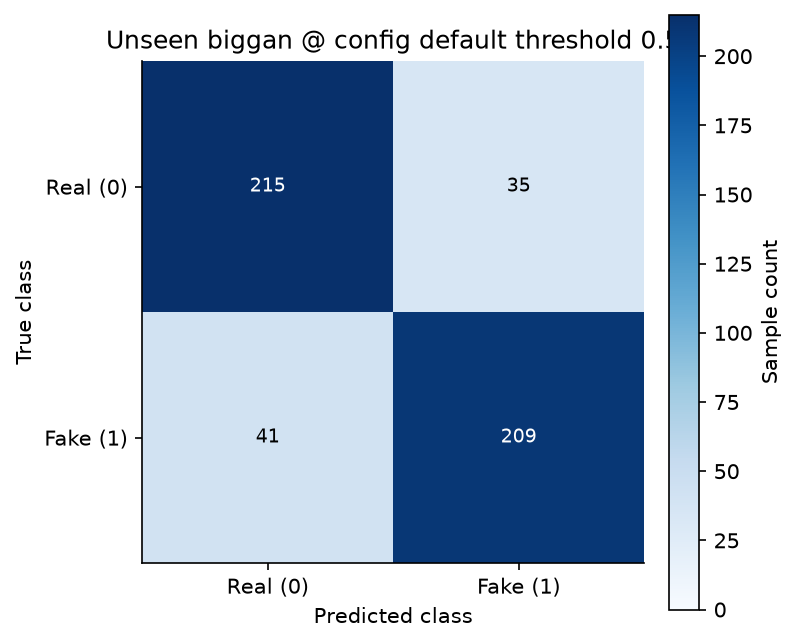

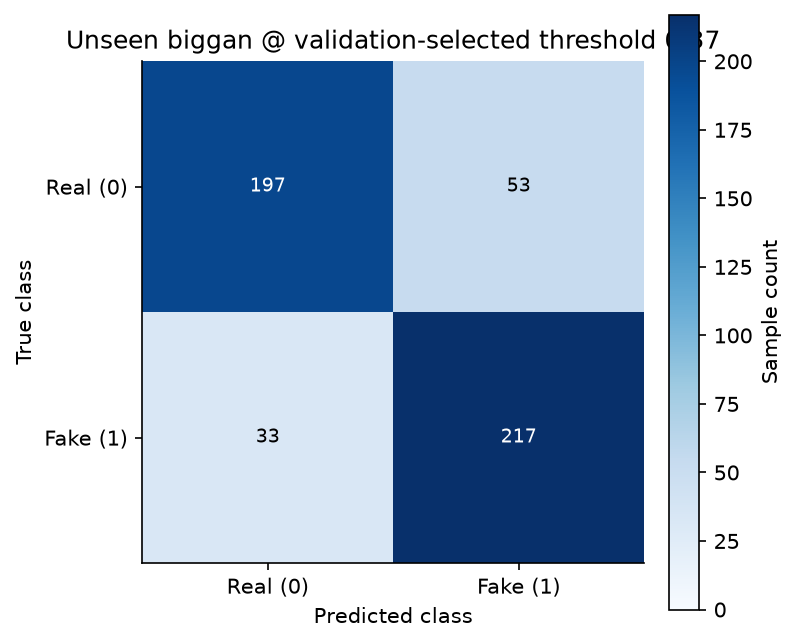

test composition: 250 held-out fakes + 250 real, prevalence 0.5


In [2]:
# Confusion matrices at each declared operating point. Counts come from the saved
# per-sample predictions; the thresholds come from the run's metrics file, so what is
# drawn is exactly what the run reported.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = metrics_for("unseen_generator")
    predictions = pd.read_csv(run / "unseen_test_predictions.csv")
    held_out = metrics["held_out_generator"]
    operating_points = {
        "config default": float(metrics["decision_threshold_default"]),
        "validation-selected": float(metrics["decision_threshold_validation_selected"]),
    }
    for name, threshold in operating_points.items():
        matrix = confusion_matrix(
            predictions["label"].tolist(),
            threshold_scores(predictions["score"].tolist(), threshold=threshold),
        )
        figure, _ = plot_confusion_matrix(
            matrix, title=f"Unseen {held_out} @ {name} threshold {threshold:g}"
        )
        display(figure)
    composition = metrics.get("final_test_composition", {})
    print(f"test composition: {composition.get('held_out_fake_count')} held-out fakes + "
          f"{composition.get('real_count')} real, prevalence "
          f"{composition.get('positive_prevalence')}")

## 2. ROC curves — does the ranking survive a new generator?

Both curves come from the same detector: one scored on generators it trained on, the other on the generator held out of training entirely. Each point on a curve is one possible threshold, tracing the trade-off between catching fakes and falsely flagging real photos.

ROC-AUC is threshold-free, which makes this the comparison least distorted by calibration drift on an unseen generator.

**How to read it:** further toward the top-left is better; the diagonal is random guessing. The gap between the two curves is the generalisation loss in ranking terms. Both test sets are prevalence-matched, so that gap is not a class-balance artefact.

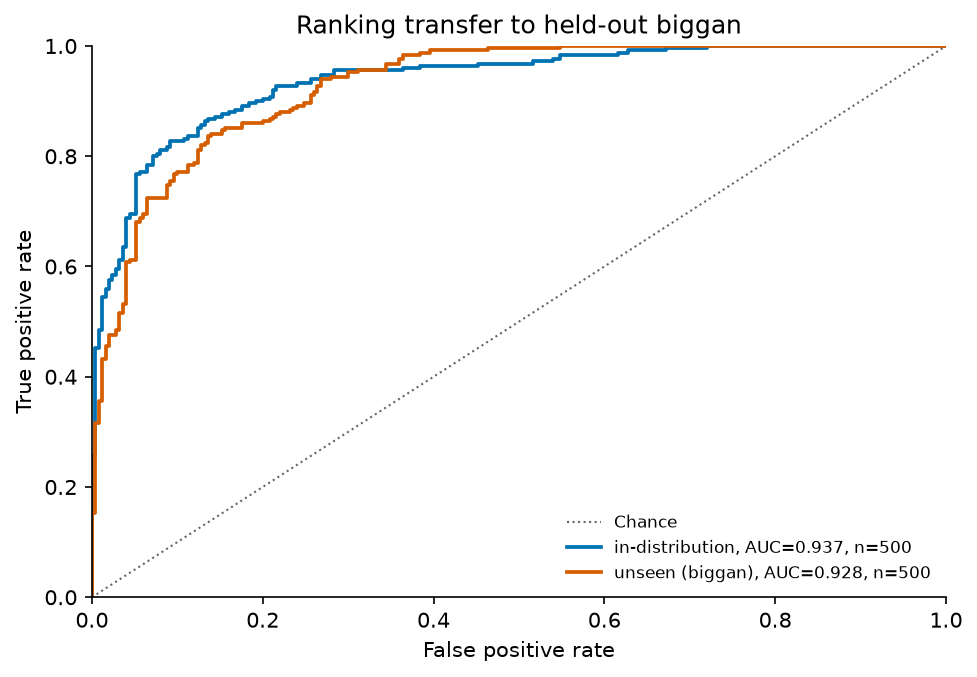

In [3]:
# ROC comparison: in-distribution versus the held-out generator, on prevalence-matched
# test sets. ROC-AUC is threshold-free, so this is the comparison least distorted by
# calibration drift on an unseen generator.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = metrics_for("unseen_generator")
    held_out = metrics["held_out_generator"]
    curves, areas, supports = {}, {}, {}
    for label, filename in (
        ("in-distribution", "in_distribution_test_predictions.csv"),
        (f"unseen ({held_out})", "unseen_test_predictions.csv"),
    ):
        path = run / filename
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        labels, scores = frame["label"].tolist(), frame["score"].tolist()
        if len(set(labels)) != 2:
            print(f"{label}: single-class slice, ROC undefined")
            continue
        computed = compute_binary_metrics(labels, scores)
        curves[label] = roc_curve_data(labels, scores)
        areas[label] = computed.roc_auc
        supports[label] = computed.support
    if curves:
        figure, _ = plot_roc_curves(
            curves, areas=areas, supports=supports,
            title=f"Ranking transfer to held-out {held_out}",
        )
        display(figure)

## 3. Precision–recall curves — performance on the fake class

The same two populations, viewed from the positive class alone. Precision is how many of the flagged images really were fake; recall is how many of the fakes present were caught. The dashed line is the prevalence of fakes, which is what a random classifier would score.

**How to read it:** both test sets are balanced 50/50, so the baseline sits at 0.5 for each. Average precision — the area under the curve — appears in the legend.

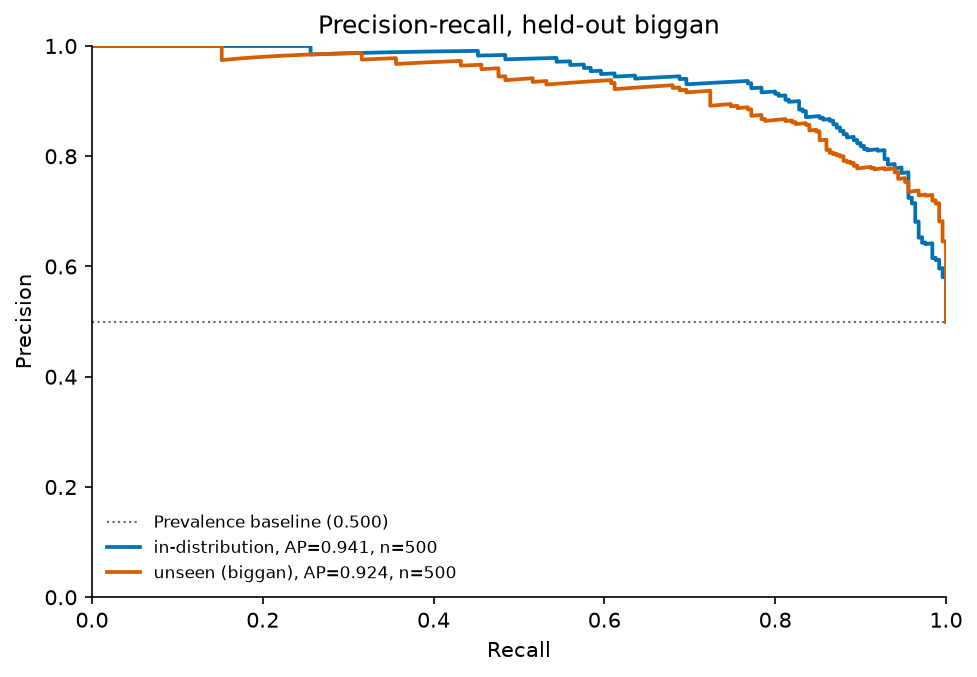

prevalence per population: [0.5, 0.5]


In [4]:
# Precision-recall against the positive-class prevalence baseline. Prevalence is taken
# from the exact plotted population, and both test sets are balanced 50/50, so the
# baseline sits at 0.5 for each.
run = RUNS["unseen_generator"]
if run is None:
    print("No completed unseen-generator run yet.")
else:
    metrics = metrics_for("unseen_generator")
    held_out = metrics["held_out_generator"]
    curves, scores_map, supports, prevalences = {}, {}, {}, []
    for label, filename in (
        ("in-distribution", "in_distribution_test_predictions.csv"),
        (f"unseen ({held_out})", "unseen_test_predictions.csv"),
    ):
        path = run / filename
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        labels, scores = frame["label"].tolist(), frame["score"].tolist()
        if len(set(labels)) != 2:
            continue
        computed = compute_binary_metrics(labels, scores)
        curves[label] = precision_recall_curve_data(labels, scores)
        scores_map[label] = computed.average_precision
        supports[label] = computed.support
        prevalences.append(sum(labels) / len(labels))
    if curves:
        figure, _ = plot_precision_recall_curves(
            curves, prevalence=sum(prevalences) / len(prevalences),
            average_precisions=scores_map, supports=supports,
            title=f"Precision-recall, held-out {held_out}",
        )
        display(figure)
        print("prevalence per population:", [round(p, 4) for p in prevalences])

## 4. Per-generator performance — what the aggregate hides

An overall score can mask a single generator the detector handles badly. This breaks performance down per generator, with the sample count for each.

**How to read it:** compare generators using **ROC-AUC**. The per-generator F1 values are *not* comparable to the overall F1, because each generator slice is scored against the whole shared real pool and therefore sits at a much lower fake prevalence. Slices containing only one class report ROC-AUC as undefined rather than zero — undefined means not measurable, not bad.

,generator,support,f1,roc_auc
0,real,1750,0.000000,NaN
1,vqdm,2000,0.489392,0.865241
2,wukong,2000,0.550882,0.899417
3,midjourney,2000,0.576000,0.931058
4,stable_diffusion_v1_5,2000,0.576000,0.927205
5,adm,2000,0.616580,0.963534
6,glide,2000,0.627249,0.974917
7,biggan,2000,0.632522,0.976103


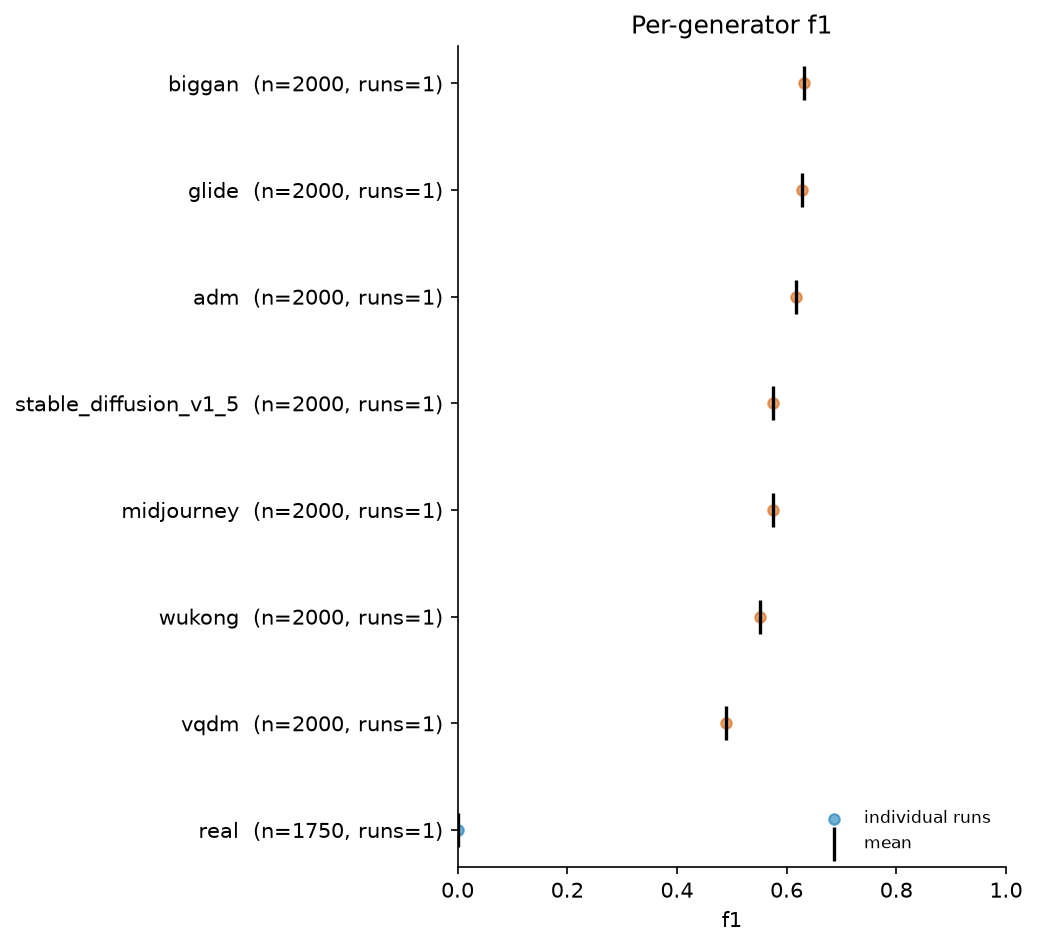

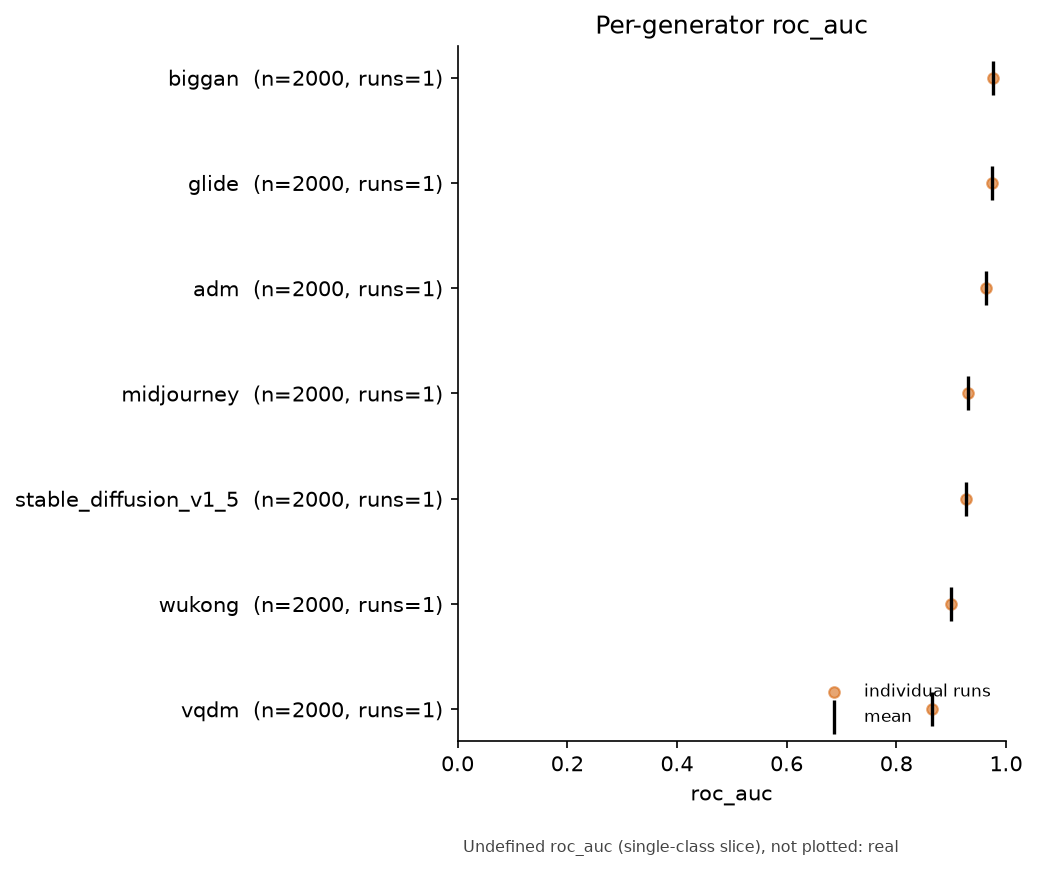

In [5]:
# Per-generator performance with support shown. Undefined single-class AUC values are
# listed as undefined rather than plotted as zero, which would read as "very bad"
# instead of "not measurable".
metrics = metrics_for("baseline")
per_generator = metrics["per_generator"] if metrics else None
if per_generator is None:
    metrics = metrics_for("unseen_generator")
    per_generator = metrics["in_distribution_test"]["per_generator"] if metrics else None

if not per_generator:
    print("No completed baseline or unseen-generator run yet.")
else:
    rows = [
        {"generator": name, "support": values["support"],
         "f1": values["f1"], "roc_auc": values["roc_auc"]}
        for name, values in per_generator.items()
    ]
    display(pd.DataFrame(rows).sort_values("f1").reset_index(drop=True))
    for metric_name in ("f1", "roc_auc"):
        if any(row[metric_name] is not None for row in rows):
            figure, _ = plot_generator_performance(rows, metric_name=metric_name)
            display(figure)


## 5. Training curves — diagnostic evidence, not results

Loss and validation metric per epoch. This describes the fitting process — underfitting, overfitting, instability — and is not test performance.

**How to read it:** the marked epoch is the one selected on validation, and that checkpoint rather than the final epoch produced every reported number. A gap that widens between the training and validation lines indicates overfitting.

,epoch,loss,split,accuracy,average_precision,f1,precision,recall,roc_auc
0,1,0.502799,train,0.752337,0.820980,0.717203,0.758195,0.680417,0.837460
1,1,0.414652,validation,0.812000,0.875135,0.789818,0.815920,0.765333,0.893154
2,2,0.346073,train,0.850340,0.919425,0.835120,0.849556,0.821167,0.927843
3,2,0.385973,validation,0.821538,0.893818,0.811811,0.790771,0.834000,0.910222
4,3,0.318911,train,0.863533,0.930892,0.850270,0.861320,0.839500,0.937887
5,3,0.372598,validation,0.838154,0.899665,0.827087,0.815824,0.838667,0.915632
6,4,0.307141,train,0.868803,0.935372,0.856530,0.864713,0.848500,0.942268
7,4,0.366905,validation,0.834769,0.903605,0.822714,0.814912,0.830667,0.918098
8,5,0.300248,train,0.872764,0.938267,0.860880,0.868993,0.852917,0.944689
9,5,0.364774,validation,0.836308,0.904292,0.823021,0.821381,0.824667,0.919005


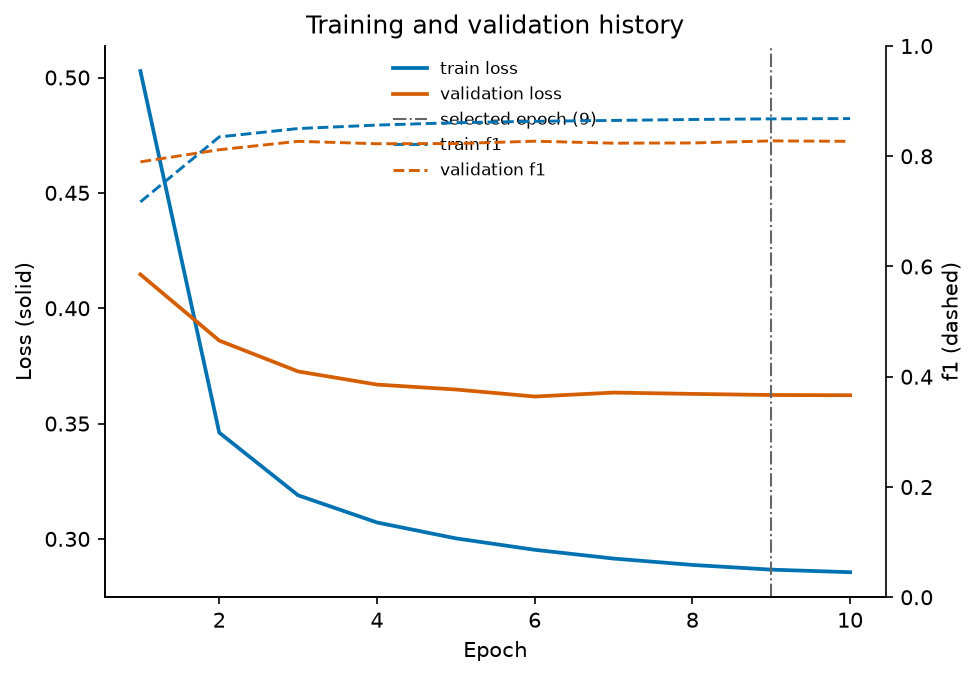

In [6]:
# Training and validation history. The validation-selected epoch is marked because that
# checkpoint, not the final epoch, produced the reported results.
experiment = next(
    (name for name in ("unseen_generator", "baseline")
     if RUNS[name] is not None and (RUNS[name] / "train_history.csv").is_file()),
    None,
)
if experiment is None:
    print("No completed run with a training history yet.")
else:
    history = pd.read_csv(RUNS[experiment] / "train_history.csv")
    display(history.head(10))
    figure, _ = plot_training_curves(
        history.to_dict(orient="records"),
        metric_name="f1",
        best_epoch=(metrics_for(experiment) or {}).get("best_epoch"),
    )
    display(figure)


## 6. Recovery curves and depth ablation

Performance against labelled budget, from the measured 0% condition through 5%, 10%, 20%, and 50%. The ablation half repeats the same grid at three adaptation depths and only appears once an ablation run exists.

Each budget is plotted at four views of the *same* saved scores: F1 at the fixed 0.5 prior, F1 at the adaptation-validation threshold, F1 at the unchanged baseline threshold, and threshold-free ROC-AUC.

**How to read it:** comparing those views separates two different explanations. If ROC-AUC stays flat while F1 climbs, the ranking did not improve and the apparent recovery is a threshold effect. If both climb, the weights genuinely adapted. The x-axis is labelled images actually consumed, including those spent on model selection.


=== fine_tuning: fine_tuning-20260808T171227711418Z-314210675e-90fa ===


,cell_id,held_out_generator,adaptation_percentage,labelled_images_consumed,roc_auc,average_precision,f1,f1_at_adaptation_threshold,f1_at_baseline_threshold,threshold_adaptation_selected,threshold_baseline_unchanged
0,zero_percent_reference,biggan,0.00,0,0.928416,0.924260,0.846154,0.834615,0.834615,NaN,0.37
1,head_only_p05_s42_t42,biggan,0.05,800,0.984288,0.983275,0.851936,0.855204,0.898048,0.45,0.37
2,head_only_p10_s42_t42,biggan,0.10,1600,0.993792,0.993456,0.895197,0.941909,0.936975,0.32,0.37
3,head_only_p20_s42_t42,biggan,0.20,3200,0.996048,0.995818,0.930233,0.937238,0.957055,0.47,0.37
4,head_only_p50_s42_t42,biggan,0.50,8000,0.997504,0.997456,0.963265,0.961145,0.979920,0.53,0.37


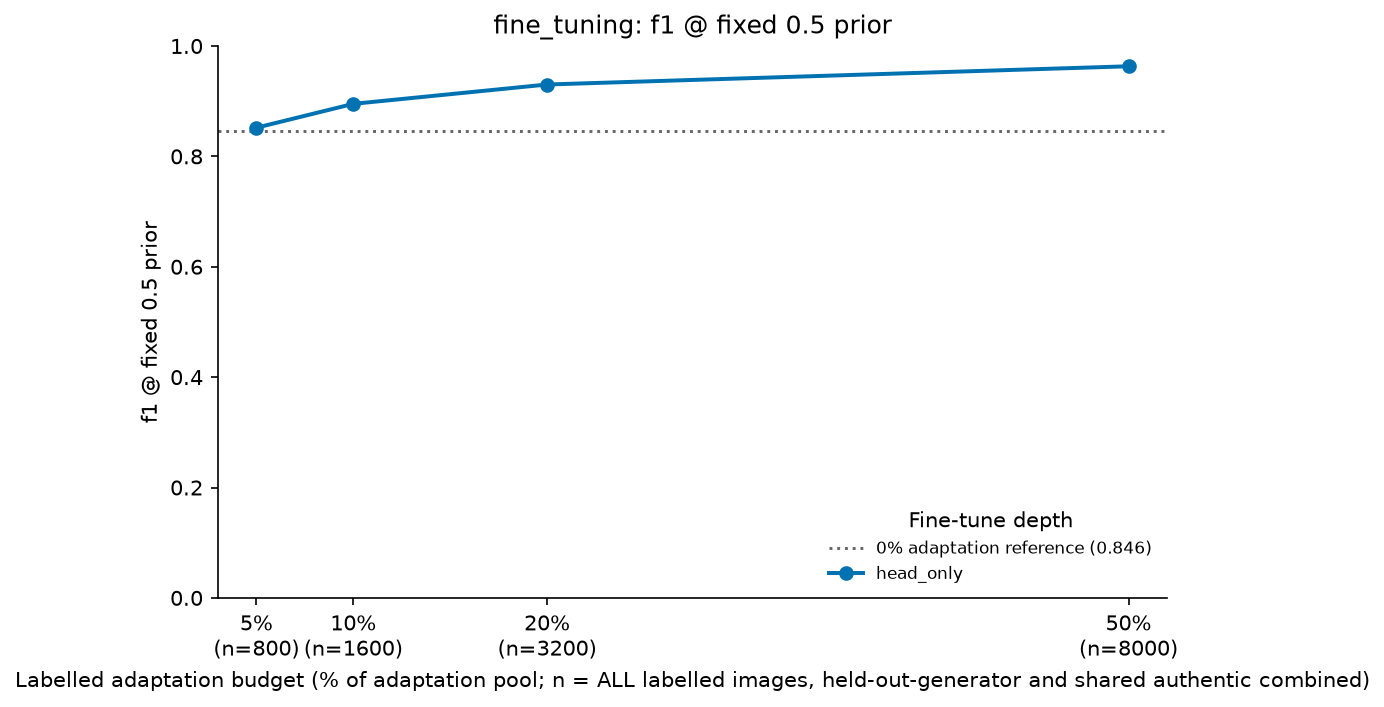

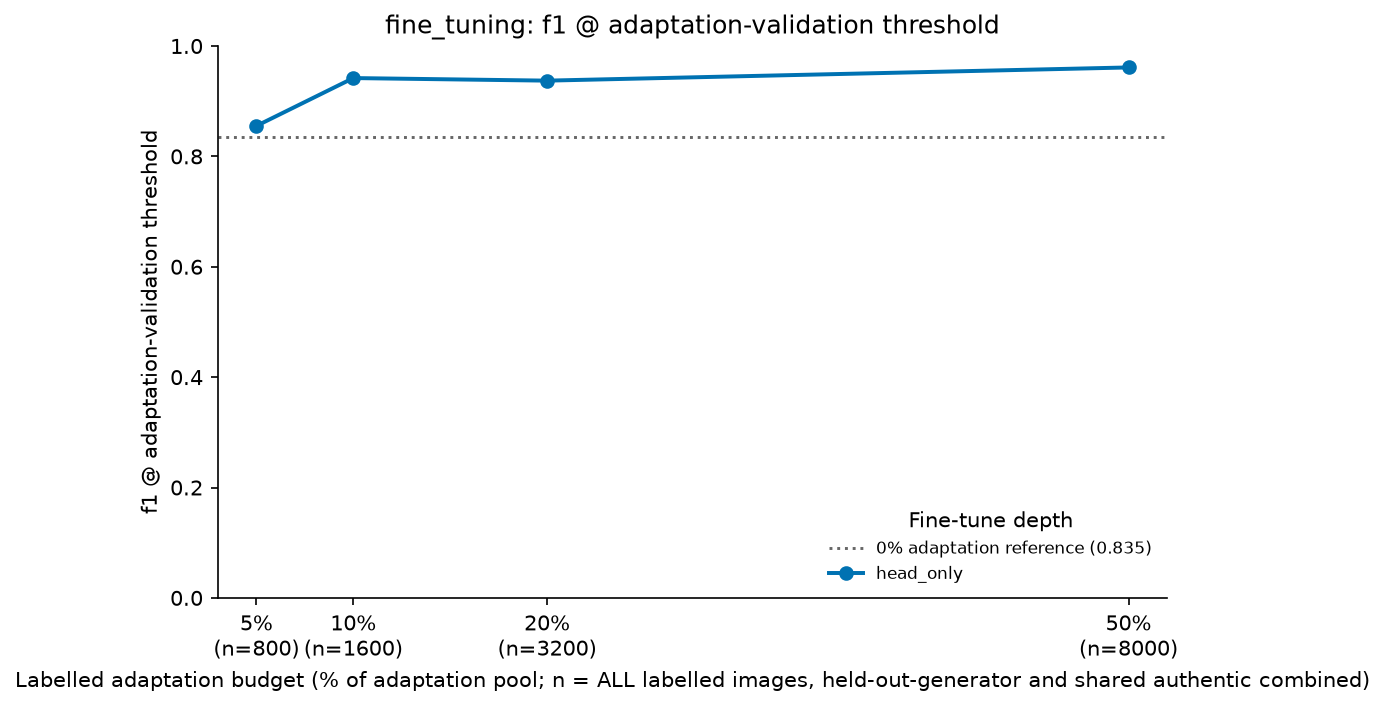

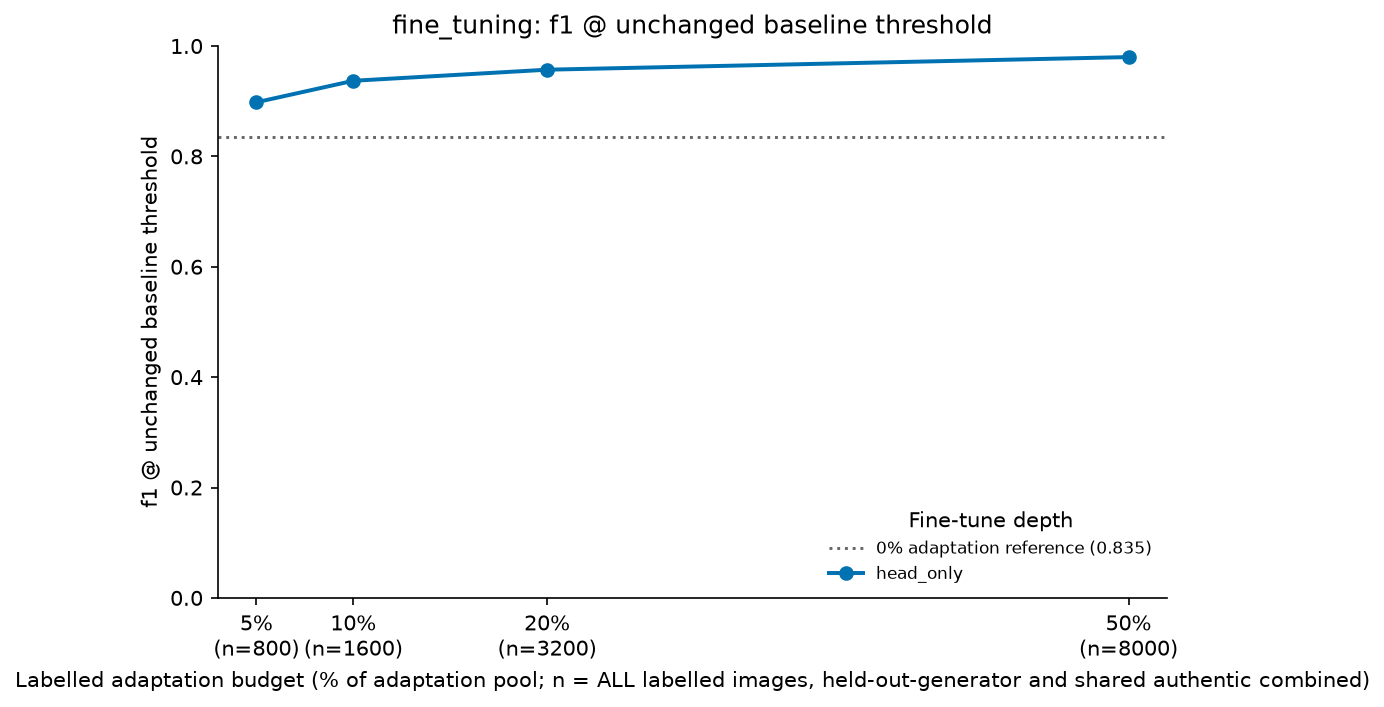

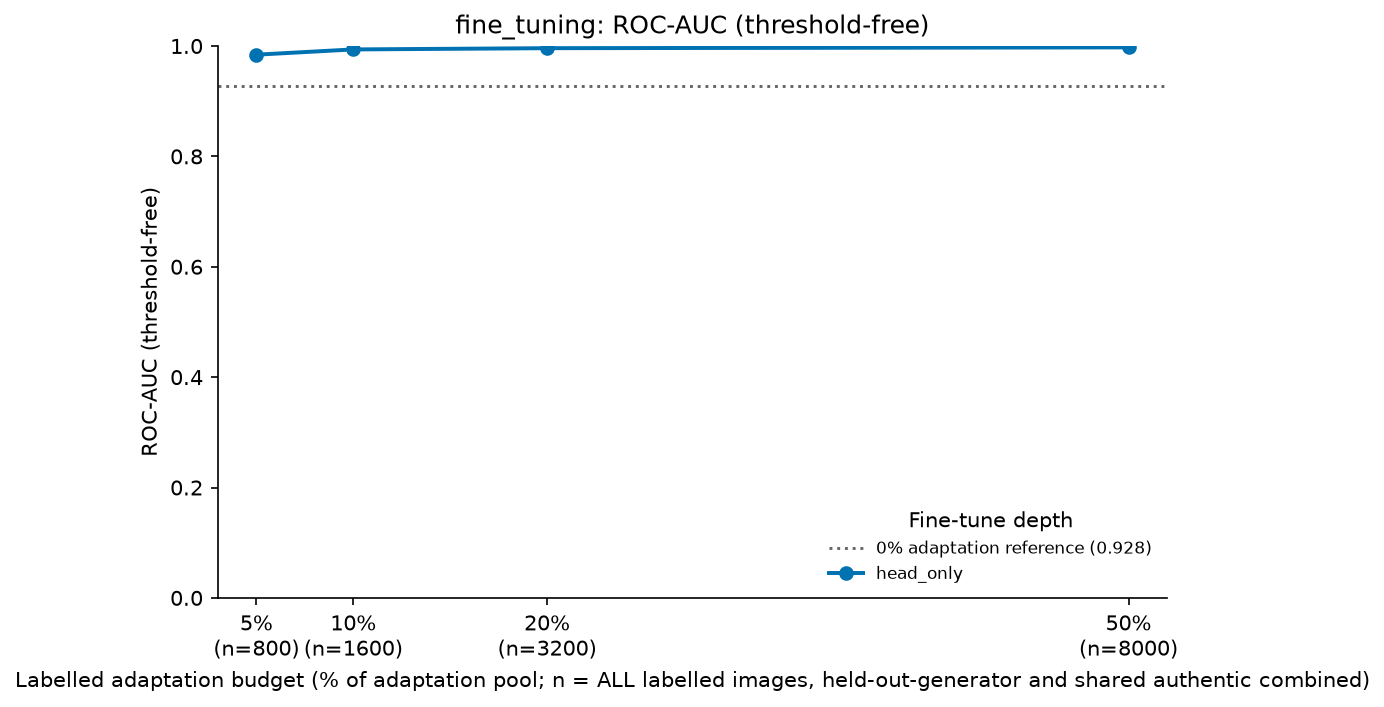

No completed ablation run yet.


In [7]:
# Recovery against labelled budget, and the depth ablation if one has been run.
#
# Each adapted model is plotted at THREE operating points. Comparing them separates
# calibration shift from genuine weight adaptation: ROC-AUC is threshold-free, so if it
# is flat while F1 climbs, the apparent recovery is a threshold effect.
for experiment in ("fine_tuning", "ablation"):
    run = RUNS[experiment]
    if run is None:
        print(f"No completed {experiment} run yet.")
        continue
    table = "recovery_cells.csv" if experiment == "fine_tuning" else "ablation_cells.csv"
    cells = pd.read_csv(run / table)
    print(f"\n=== {experiment}: {run.name} ===")
    columns = [c for c in [
        "cell_id", "held_out_generator", "adaptation_percentage", "labelled_images_consumed",
        "roc_auc", "average_precision", "f1", "f1_at_adaptation_threshold",
        "f1_at_baseline_threshold", "threshold_adaptation_selected",
        "threshold_baseline_unchanged"] if c in cells.columns]
    display(cells[columns])
    for metric_column, label in (
        ("f1", "f1 @ fixed 0.5 prior"),
        ("f1_at_adaptation_threshold", "f1 @ adaptation-validation threshold"),
        ("f1_at_baseline_threshold", "f1 @ unchanged baseline threshold"),
        ("roc_auc", "ROC-AUC (threshold-free)"),
    ):
        if metric_column not in cells.columns or cells[metric_column].isna().all():
            continue
        rows = cells.rename(columns={metric_column: "metric"}).to_dict(orient="records")
        for row in rows:
            row[metric_column] = row["metric"]
        try:
            figure, axes = plot_fine_tuning_recovery(rows, metric_name=metric_column)
            axes.set_title(f"{experiment}: {label}")
            axes.set_ylabel(label)
            display(figure)
        except ValueError as error:
            print(f"  {label}: {error}")

## 7. Cross-run comparison figures

The figures above each describe one run. These describe the study: they pool **every**
reportable run, so a leave-one-generator-out sweep or a depth ablation appears here as
soon as it exists, without this notebook changing.

They are built from the same consolidated table that
`python -m scripts.build_report` writes to
`outputs/report/consolidated/consolidated_results.csv`, where every row names the run and
the hashed metrics file it came from.


46 evaluated conditions from 3 reportable runs


,run_id,held_out_generator,operating_point,metric,in_distribution,unseen,absolute_drop,relative_drop,in_distribution_prevalence,unseen_prevalence,unseen_support
0,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,roc_auc,0.937376,0.928416,0.008960,0.009559,0.5,0.5,500
1,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,average_precision,0.941380,0.924260,0.017121,0.018187,0.5,0.5,500
2,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,f1,0.864542,0.846154,0.018388,0.021269,0.5,0.5,500
3,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,accuracy,0.864000,0.848000,0.016000,0.018519,0.5,0.5,500
4,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,precision,0.861111,0.856557,0.004554,0.005288,0.5,0.5,500
5,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,default,recall,0.868000,0.836000,0.032000,0.036866,0.5,0.5,500
6,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,validation_selected,roc_auc,NaN,0.928416,NaN,NaN,NaN,0.5,500
7,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,validation_selected,average_precision,NaN,0.924260,NaN,NaN,NaN,0.5,500
8,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,validation_selected,f1,NaN,0.834615,NaN,NaN,NaN,0.5,500
9,unseen_generator-20260808T151948963300Z-c74c3e...,biggan,validation_selected,accuracy,NaN,0.828000,NaN,NaN,NaN,0.5,500


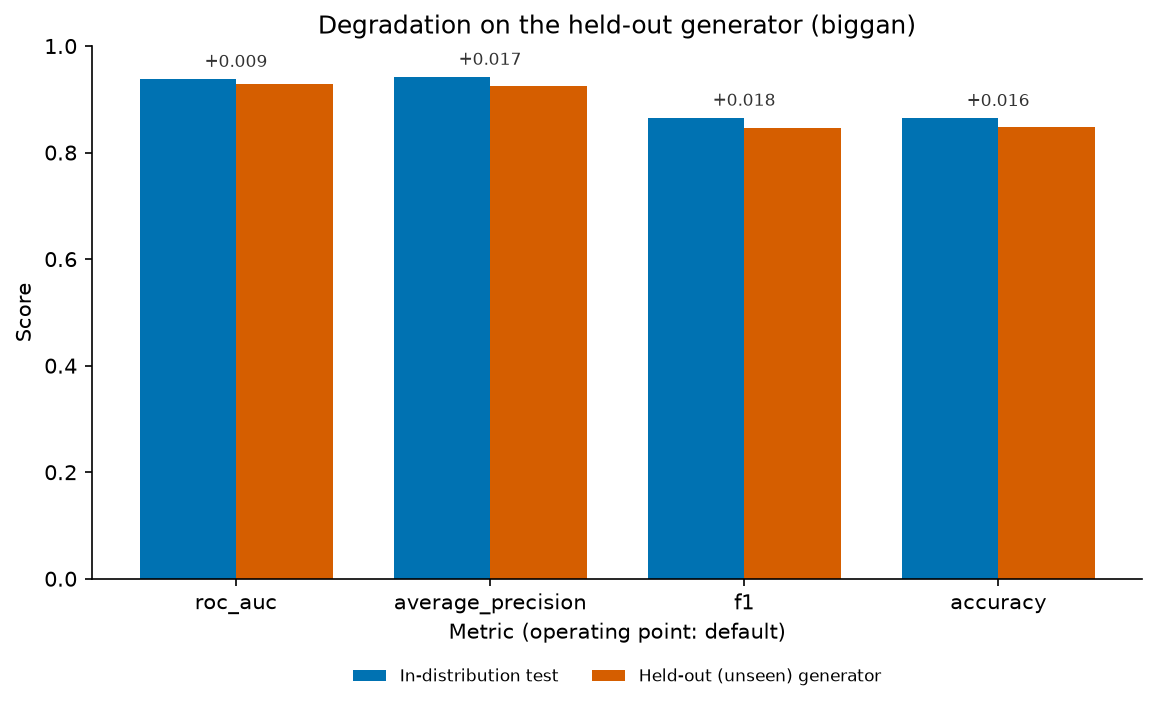

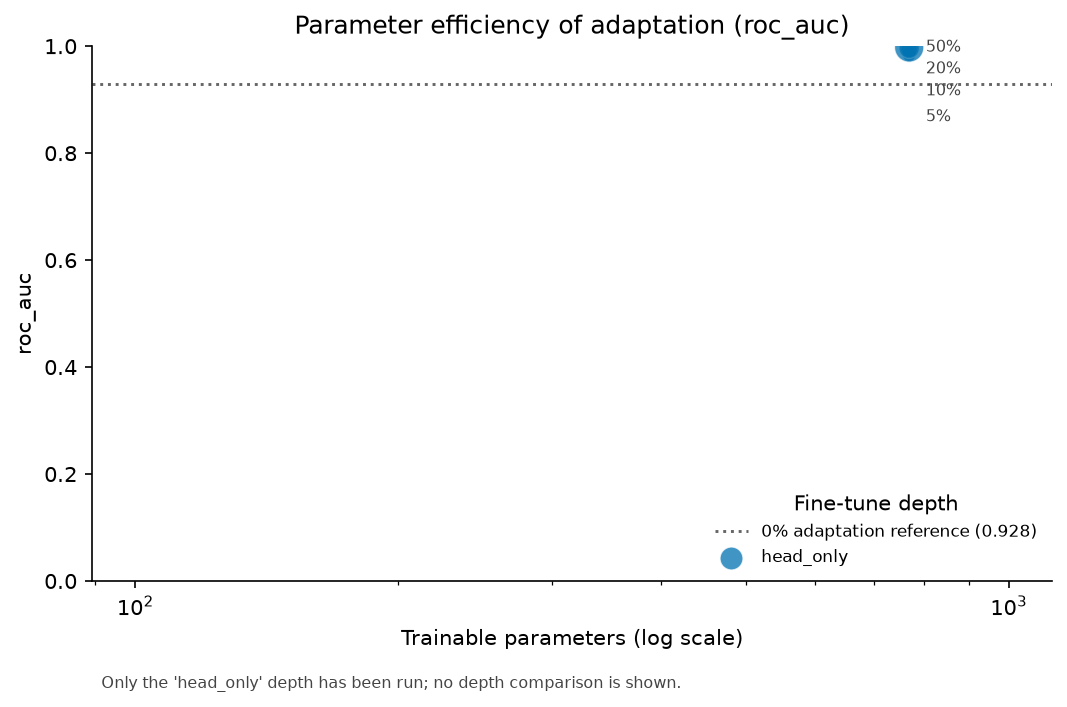

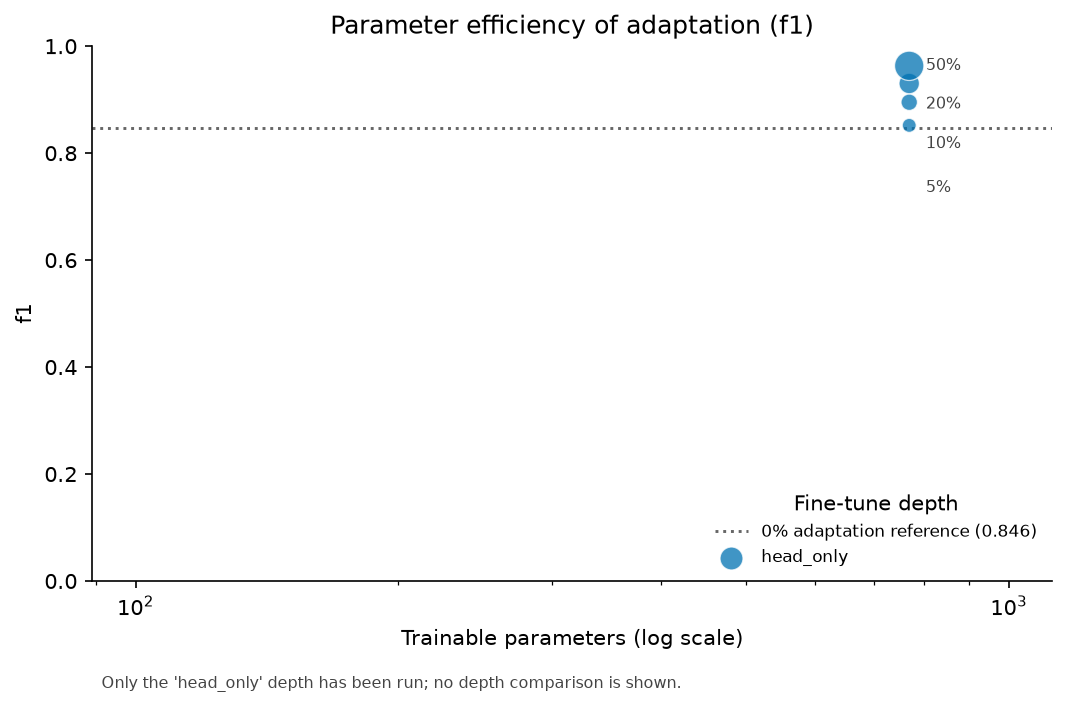

In [8]:
# Cross-run figures, built from the consolidated table rather than from any single run.
from src.evaluation.aggregation import consolidate_runs, degradation_rows

CONSOLIDATED = consolidate_runs(REPORTABLE)
print(f"{len(CONSOLIDATED)} evaluated conditions from {len(REPORTABLE)} reportable runs")

# Degradation: in-distribution versus the held-out generator, at one operating point.
degradation = degradation_rows(CONSOLIDATED)
if not degradation:
    print("No unseen-generator run has measured both sides yet.")
else:
    display(pd.DataFrame(degradation))
    figure, _ = plot_generalisation_degradation(degradation, operating_point="default")
    display(figure)

# Parameter efficiency: what each depth bought for the parameters it trained. Becomes a
# real trade-off once the ablation supplies last_block and full.
cells = [
    row for row in CONSOLIDATED
    if row["experiment_type"] in {"fine_tuning", "ablation"}
    and row["generator"] is None
    and row["operating_point"] == "default"
]
adapted = [row for row in cells if (row["adaptation_percentage"] or 0.0) > 0.0]
for metric in ("roc_auc", "f1"):
    zero = next(
        (row[metric] for row in cells
         if (row["adaptation_percentage"] or 0.0) == 0.0 and row[metric] is not None),
        None,
    )
    try:
        figure, _ = plot_parameter_efficiency(
            adapted, metric_name=metric, zero_percent_reference=zero
        )
        display(figure)
    except ValueError as error:
        print(f"parameter efficiency ({metric}): {error}")
